# IMAX LBO — Credit Risk Analysis

This notebook models the **credit risk profile** of IMAX Corporation (IMAX) in the context of a hypothetical leveraged buyout (LBO). It is structured as a self-contained analysis pipeline that pulls live data and produces interpretable outputs for a credit committee or investment team.

**Tech stack:** Python · `yfinance` · `pandas` · `numpy` · `scipy` · `matplotlib`

---

## Analysis Roadmap

| Section | What it does |
|---------|-------------|
| **1. Data** | Pulls latest financials from Yahoo Finance; normalises inconsistent field names |
| **2. Credit Metrics** | Computes Net Debt/EBITDA, Interest Coverage, and Altman Z-Score |
| **3. Merton Model** | Solves for implied asset value, asset volatility, distance-to-default, and 1-year PD |
| **4. Debt Capacity** | Shows nominal vs risk-adjusted IRR across leverage levels — reveals the risk "cliff" |
| **5. Covenant Analysis** | Illustrative covenant headroom and stress-test under a revenue/margin shock |
| **6. Sensitivity** | Joint revenue × margin sensitivity grids for Leverage and ICR |
| **7. Summary Chart** | Four-panel dashboard comparing IMAX metrics to LBO benchmarks |

## 1. Setup & Data

All imports and helper functions live here so the rest of the notebook reads cleanly.

**Key helper — `get_val(series, *keys)`**: Yahoo Finance uses inconsistent row-label conventions across statement types. This function does a case-insensitive substring search so we can reliably find revenue, EBITDA, interest expense, etc. without brittle hard-coded index lookups.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import Markdown, display

# ── Chart defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
})
C_NAVY, C_BLUE, C_RED, C_ORANGE, C_GREEN, C_PURPLE = (
    "#002060", "steelblue", "red", "#ED7D31", "#375623", "#7030A0"
)

# ── Helper functions ────────────────────────────────────────────────────────
def first_col(df):
    """Return the most-recent column of a financial statement DataFrame."""
    return df.iloc[:, 0] if df is not None and not df.empty else pd.Series(dtype=float)


def get_val(series, *keys):
    """
    Find the first matching row value using case-insensitive substring search.

    Yahoo Finance uses CamelCase labels without spaces ('TotalAssets') while
    human-readable keys use spaces ('total assets'). This function strips all
    spaces before comparing so both forms match correctly.
    """
    if series is None or series.empty:
        return np.nan
    for key in keys:
        key_norm = key.lower().replace(" ", "")
        for idx in series.index:
            if key_norm in str(idx).lower().replace(" ", ""):
                return series[idx]
    return np.nan


TICKER = "IMAX"
t = yf.Ticker(TICKER)

# ── Pull statements ─────────────────────────────────────────────────────────
def _fetch(primary, fallback):
    """Return primary DataFrame if non-empty, otherwise fall back."""
    return primary if primary is not None and not primary.empty else fallback

income   = _fetch(t.get_income_stmt(freq="yearly"),   t.income_stmt)
balance  = _fetch(t.get_balance_sheet(freq="yearly"), t.balance_sheet)
cashflow = _fetch(t.get_cashflow(freq="yearly"),      t.cashflow)

inc = first_col(income)
bal = first_col(balance)
cf  = first_col(cashflow)
_info = t.info or {}

# ── Extract income-statement items ──────────────────────────────────────────
revenue      = get_val(inc, "total revenue", "revenue")
ebit         = get_val(inc, "ebit", "operating income")
ebitda_raw   = get_val(inc, "ebitda")
net_income   = get_val(inc, "net income", "net income common")
interest_exp = get_val(inc, "interest expense", "interest expense debt", "net interest")

# Fallback: try TTM if annual statement has no interest line
if (pd.isna(interest_exp) or interest_exp == 0) and hasattr(t, "ttm_income_stmt"):
    try:
        ttm_ser = first_col(t.ttm_income_stmt)
        interest_exp = get_val(ttm_ser, "interest expense", "net interest")
    except Exception:
        pass

# ── Extract balance-sheet items ─────────────────────────────────────────────
_ta = get_val(bal, "total assets")
total_assets = float(_info.get("totalAssets", 0) or 0) if pd.isna(_ta) else _ta
total_equity = get_val(bal, "total stockholders equity", "total equity")
_tl = get_val(bal, "total liabilities", "total liabilities net minority")
total_liab   = float(_info.get("totalLiabilities", np.nan) or np.nan) if pd.isna(_tl) else _tl

# Debt: prefer balance-sheet sum; fall back to t.info
st_debt   = get_val(bal, "short term debt", "current debt")
lt_debt   = get_val(bal, "long term debt", "long term debt and capital lease")
_td = get_val(bal, "total debt")
_st_sum = (0 if pd.isna(st_debt) else st_debt) + (0 if pd.isna(lt_debt) else lt_debt)
total_debt = (_td if not pd.isna(_td) else
              _st_sum if _st_sum > 0 else
              float(_info.get("totalDebt", 0) or 0))

cash = get_val(bal, "cash and equivalents", "cash")
if pd.isna(cash) or cash == 0:
    cash = float(_info.get("totalCash", 0) or 0)

current_assets    = get_val(bal, "current assets", "total current assets")
current_liab      = get_val(bal, "current liabilities", "total current liabilities")
retained_earnings = get_val(bal, "retained earnings")

# ── EBITDA: use direct field if available, else EBIT + D&A ─────────────────
dda = get_val(cf, "depreciation amortization", "depreciation and amortization")
if pd.isna(ebitda_raw) and not (pd.isna(ebit) and pd.isna(dda)):
    ebitda_raw = (ebit or 0) + (dda or 0)

# ── Market data ─────────────────────────────────────────────────────────────
hist = t.history(period="2y")
equity_vol_annual = hist["Close"].pct_change().dropna().std() * np.sqrt(252) \
    if hist is not None and not hist.empty and len(hist) > 20 else np.nan

shares = _info.get("sharesOutstanding") or _info.get("floatShares")
price  = _info.get("currentPrice") or (hist["Close"].iloc[-1] if hist is not None and not hist.empty else np.nan)
market_cap = float(shares * price) if shares and price and price > 0 else np.nan

# ── Consolidated inputs dict ────────────────────────────────────────────────
data = {
    "revenue":           revenue,
    "ebit":              ebit,
    "ebitda":            ebitda_raw,
    "net_income":        net_income,
    "interest_exp":      interest_exp,
    "total_assets":      total_assets,
    "total_equity":      total_equity,
    "total_debt":        total_debt if not pd.isna(total_debt) else 0,
    "cash":              cash if not pd.isna(cash) else 0,
    "current_assets":    current_assets,
    "current_liab":      current_liab,
    "retained_earnings": retained_earnings,
    "total_liab":        total_liab,
    "market_cap":        market_cap,
    "equity_vol_annual": equity_vol_annual,
}

print("Latest fiscal year inputs (from Yahoo Finance):")
pd.Series({k: v for k, v in data.items() if v is not None and not (isinstance(v, float) and np.isnan(v))})

Latest fiscal year inputs (from Yahoo Finance):


revenue              4.102120e+08
ebit                 1.587100e+08
ebitda               1.587100e+08
net_income           3.487600e+07
interest_exp         7.362000e+06
total_assets         8.940310e+08
total_equity         4.277330e+08
total_debt           2.786110e+08
cash                 1.511680e+08
current_assets       3.740420e+08
current_liab         2.565550e+08
retained_earnings   -6.086000e+06
total_liab           4.662980e+08
market_cap           2.086290e+09
equity_vol_annual    3.542793e-01
dtype: float64

## 2. Core Credit Metrics

Three standard LBO credit-screening ratios:

| Metric | What it measures | Typical threshold |
|--------|-----------------|------------------|
| **Net Debt / EBITDA** | Repayment capacity; how many years of earnings to retire debt | ~4–6× for LBO financing |
| **Interest Coverage (EBITDA / Interest)** | Ability to service debt from operating cash flow | ≥ 2× lender floor |
| **Altman Z-Score** | Composite solvency signal using five accounting ratios | > 2.99 = safe; 1.81–2.99 = grey; < 1.81 = distress |

In [2]:
# ── Compute metrics ─────────────────────────────────────────────────────────
net_debt     = data["total_debt"] - data["cash"]
ebitda       = data["ebitda"]
interest_exp = data["interest_exp"]

leverage = net_debt / ebitda if ebitda and ebitda > 0 else np.nan

if interest_exp and interest_exp > 0:
    interest_coverage = ebitda / interest_exp
else:
    interest_coverage = np.inf if ebitda and ebitda > 0 else np.nan

# Altman Z-Score (Altman 1968 — public-company version)
ta      = data["total_assets"]
wc      = (data["current_assets"] or 0) - (data["current_liab"] or 0)
re      = data["retained_earnings"] or 0
ebit_   = data["ebit"] or 0
mve     = data["market_cap"] or (data["total_equity"] or 0)   # market value of equity
bv_liab = data["total_liab"] or 0
sales   = data["revenue"] or 0

if ta and ta > 0:
    A = wc / ta
    B = re / ta
    C = ebit_ / ta
    D = (mve / bv_liab) if bv_liab > 0 else 0
    E = sales / ta
    altman_z = 1.2*A + 1.4*B + 3.3*C + 0.6*D + 1.0*E
else:
    altman_z = np.nan

z_band = ("safe" if altman_z > 2.99 else
          "grey" if altman_z >= 1.81 else
          "distress") if not np.isnan(altman_z) else "n/a"

# ── Display results ─────────────────────────────────────────────────────────
print("Base credit metrics (current profile):")
display(pd.Series({
    "Net Debt":                         net_debt,
    "EBITDA":                           ebitda,
    "Leverage (Net Debt/EBITDA)": leverage,
    "Interest Coverage (EBITDA/Int)": interest_coverage,
    "Altman Z-Score":                  altman_z,
}))

fmt_lev = lambda x: f"{x:.2f}×" if not np.isnan(x) else "n/a"
fmt_icr = lambda x: "∞ (no interest in filing)" if x == np.inf else (f"{x:.1f}×" if not np.isnan(x) else "n/a")

display(Markdown(f"""
### Interpretation

- **Leverage** {fmt_lev(leverage)} — well below the rough 3–4× LBO comfort zone; IMAX carries substantial headroom if EBITDA holds.
- **Interest coverage** {fmt_icr(interest_coverage)} — comfortably above a ~2× lender floor; debt service capacity looks strong.
- **Altman Z** {altman_z:.2f} ({z_band}) — snapshot indicator; not a credit-rating substitute.
"""))

Base credit metrics (current profile):


Net Debt                          1.274430e+08
EBITDA                            1.587100e+08
Leverage (Net Debt/EBITDA)        8.029929e-01
Interest Coverage (EBITDA/Int)    2.155800e+01
Altman Z-Score                    3.877315e+00
dtype: float64


### Interpretation

- **Leverage** 0.80× — well below the rough 3–4× LBO comfort zone; IMAX carries substantial headroom if EBITDA holds.
- **Interest coverage** 21.6× — comfortably above a ~2× lender floor; debt service capacity looks strong.
- **Altman Z** 3.88 (safe) — snapshot indicator; not a credit-rating substitute.


## 3. Merton Distance-to-Default (1-Year PD)

The **Merton (1974)** structural credit model treats equity as a call option on the firm's assets. Given observable equity value **E** and equity volatility **σ_E**, we back-solve for:
- **V** — implied total asset value
- **σ_V** — implied asset volatility
- **DD** = distance-to-default (how many standard deviations away from insolvency)
- **PD** = N(−DD) — risk-neutral 1-year probability of default

This is a *market-implied* credit check, not a bank rating model.

In [3]:
def merton_dd_pd(E, sigma_E, F, r=0.05, T=1.0):
    """
    Solve the Merton structural credit model.

    Parameters
    ----------
    E       : float  — current equity market cap
    sigma_E : float  — annualised equity return volatility
    F       : float  — face value of debt (default boundary)
    r       : float  — risk-free rate (default 5%)
    T       : float  — time horizon in years (default 1)

    Returns
    -------
    V, sigma_V, DD, PD : implied asset value, asset vol, distance-to-default, 1Y PD
    """
    if E <= 0 or sigma_E <= 0 or F <= 0:
        return np.nan, np.nan, np.nan, np.nan

    def equations(x):
        V, sV = x[0], max(x[1], 1e-9)
        d1 = (np.log(V / F) + (r + 0.5 * sV**2) * T) / (sV * np.sqrt(T))
        d2 = d1 - sV * np.sqrt(T)
        # Merton equity pricing formula & volatility linkage
        eq1 = V * norm.cdf(d1) - F * np.exp(-r * T) * norm.cdf(d2) - E
        eq2 = (V / E) * norm.cdf(d1) * sV - sigma_E
        return [eq1, eq2]

    try:
        V0, s0 = E + F, sigma_E * E / (E + F)   # seed from naive leverage
        sol, *_ = fsolve(equations, [V0, s0], full_output=True)
        V, sV   = sol[0], max(sol[1], 1e-6)
        d2      = (np.log(V / F) + (r - 0.5 * sV**2) * T) / (sV * np.sqrt(T))
        DD      = d2
        PD      = norm.cdf(-DD)
        return V, sV, DD, PD
    except Exception:
        return np.nan, np.nan, np.nan, np.nan


# ── Run the model ────────────────────────────────────────────────────────────
E_merton  = data["market_cap"] if not pd.isna(data["market_cap"]) else data["total_equity"]
sigma_E   = data["equity_vol_annual"] if not pd.isna(data["equity_vol_annual"]) and data["equity_vol_annual"] > 0 else 0.35
F_debt    = max(data["total_debt"] or 1, 1)   # debt face value

V_asset, sigma_V, DD, PD = merton_dd_pd(E_merton, sigma_E, F_debt, r=0.05, T=1.0)

pd_str = "<0.01%" if PD < 0.0001 else f"{PD:.2%}"
print(f"Merton results  →  V = ${V_asset/1e9:.2f}B  |  σ_V = {sigma_V:.2%}  |  DD = {DD:.2f}  |  PD(1Y) = {pd_str}")

display(Markdown(f"""
### Interpretation

| Output | Value | Note |
|--------|-------|------|
| Implied asset value **V** | ${V_asset/1e9:.2f}B | Model-implied (≠ book) |
| Asset volatility **σ_V** | {sigma_V:.1%} p.a. | Lower than equity vol — expected |
| Distance-to-default **DD** | {DD:.2f} std devs | Higher = safer |
| 1-Year PD | {pd_str} | r=5%, T=1Y, F=balance-sheet debt |

A high DD means the asset value is several standard deviations above the default
boundary — consistent with the low leverage observed in §2.
"""))

Merton results  →  V = $2.35B  |  σ_V = 31.43%  |  DD = 6.79  |  PD(1Y) = <0.01%



### Interpretation

| Output | Value | Note |
|--------|-------|------|
| Implied asset value **V** | $2.35B | Model-implied (≠ book) |
| Asset volatility **σ_V** | 31.4% p.a. | Lower than equity vol — expected |
| Distance-to-default **DD** | 6.79 std devs | Higher = safer |
| 1-Year PD | <0.01% | r=5%, T=1Y, F=balance-sheet debt |

A high DD means the asset value is several standard deviations above the default
boundary — consistent with the low leverage observed in §2.


## 4. Debt Capacity Curve — Nominal vs Risk-Adjusted IRR

An illustrative post-LBO model that shows how equity IRR varies with leverage. Two curves are shown:

- **Nominal IRR** — standard DCF return assuming fixed exit multiple, EBITDA growth, and step-up cost of debt.
- **Risk-adjusted IRR** — applies a penalty above 6.0× (1.5 pp per 1× increment) to capture covenant friction, refi risk, and distress costs.

The gap between the two curves is **the cliff** — the point at which adding leverage destroys rather than creates equity value.

> **Model assumptions are illustrative.** Plug in your term sheet to make this production-ready.

BASE_EBITDA : $158.7M
Entry EV    : $1,904.5M  (12×)
Exit EV     : $3,264.8M  (14× on year-5 EBITDA)

Peak nominal IRR : 16.6% at 5.9×
IRR @ 4.5× (proposed) : 15.6%


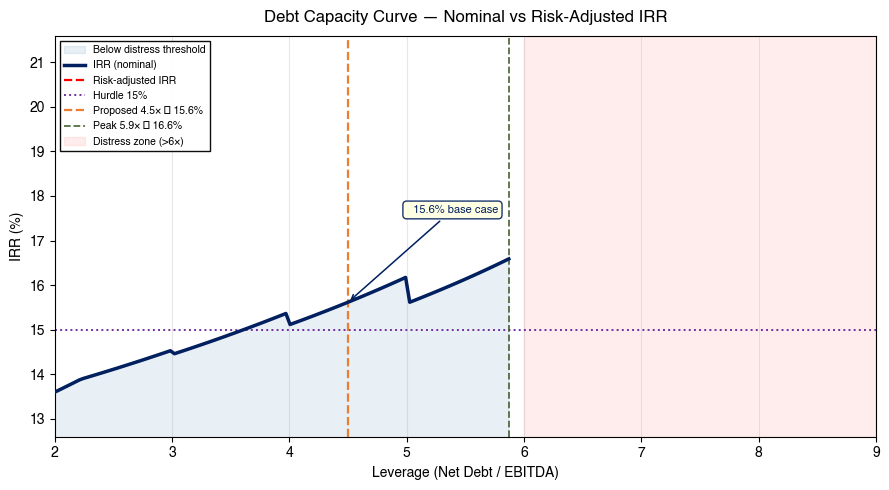


**Reading the chart:**
- **Blue** = nominal IRR. **Red dashed** = risk-adjusted (penalty kicks in above 6.0×).
- The gap between the two curves is **the cliff** — where leverage destroys equity value.
- **Purple dotted** = fund hurdle rate. **Orange** = proposed deal leverage.


In [ ]:
# ── Model parameters ────────────────────────────────────────────────────────
HOLD_YEARS    = 5
ENTRY_MULT    = 12.0   # EV/EBITDA at entry
EXIT_MULT     = 14.0   # EV/EBITDA at exit
EBITDA_GROWTH = 0.08   # annual EBITDA growth rate
BASE_EBITDA   = float(data["ebitda"]) if data.get("ebitda") and data["ebitda"] > 0 else 130e6
PROPOSED_LEV  = 4.5    # proposed leverage for deal annotation
DISTRESS_LEV  = 6.0    # leverage threshold for distress zone
HURDLE        = 15.0   # IRR hurdle rate (%)

print(f"BASE_EBITDA : ${BASE_EBITDA/1e6:,.1f}M")
print(f"Entry EV    : ${ENTRY_MULT * BASE_EBITDA/1e6:,.1f}M  ({ENTRY_MULT:.0f}×)")
print(f"Exit EV     : ${EXIT_MULT * BASE_EBITDA * (1+EBITDA_GROWTH)**HOLD_YEARS/1e6:,.1f}M  ({EXIT_MULT:.0f}× on year-{HOLD_YEARS} EBITDA)")


def lbo_irr(lev, base_ebitda=BASE_EBITDA):
    """
    Estimate equity IRR for a given leverage multiple.

    Logic
    -----
    1. Equity injected = (1 − lev/entry_mult) × entry_EV
    2. Cost of debt steps up with leverage (reflects real market pricing).
    3. ICR gate: reject if EBITDA / interest < 2× (basic lender test).
    4. Partial debt paydown from FCF over the hold period.
    5. Exit equity = exit_EV − residual_debt − cumulative_interest.
    6. IRR = (exit_equity / equity_invested)^(1/T) − 1.
    """
    equity_share = 1 - lev / ENTRY_MULT
    if equity_share <= 0.15:
        return np.nan   # too little equity — unrealistic

    debt = lev * base_ebitda

    # Step-up cost of debt schedule (basis-points spread)
    if   lev <= 3.0: rd = 0.055
    elif lev <= 4.0: rd = 0.060
    elif lev <= 5.0: rd = 0.070
    elif lev <= 6.0: rd = 0.085
    else:            rd = 0.10 + 0.015 * (lev - 6)

    annual_interest = debt * rd
    if annual_interest == 0 or (base_ebitda / annual_interest) < 2.0:
        return np.nan   # fails ICR gate

    # Partial paydown: 50% of FCF (40% EBITDA margin) swept to debt
    fcf_annual   = base_ebitda * 0.40
    debt_paydown = min(fcf_annual * 0.50 * HOLD_YEARS, debt * 0.45)

    ebitda_exit  = base_ebitda * (1 + EBITDA_GROWTH)**HOLD_YEARS
    exit_ev      = EXIT_MULT * ebitda_exit
    debt_exit    = max(0, debt - debt_paydown)
    cum_interest = annual_interest * HOLD_YEARS

    equity_invested = equity_share * ENTRY_MULT * base_ebitda
    equity_exit     = exit_ev - debt_exit - cum_interest

    if equity_invested <= 0 or equity_exit <= 0:
        return np.nan

    return ((equity_exit / equity_invested)**(1 / HOLD_YEARS) - 1) * 100


# ── Compute curves ──────────────────────────────────────────────────────────
lev_range  = np.linspace(2, 9, 200)
irrs       = np.array([lbo_irr(lev) for lev in lev_range], dtype=float)
valid      = ~np.isnan(irrs)

risk_adj   = irrs.copy()
for i, lev in enumerate(lev_range):
    if not np.isnan(risk_adj[i]) and lev > DISTRESS_LEV:
        risk_adj[i] = max(0, risk_adj[i] - (lev - DISTRESS_LEV) * 1.5)

if valid.any():
    peak_lev  = lev_range[np.nanargmax(irrs)]
    peak_irr  = irrs[np.nanargmax(irrs)]
    prop_irr  = lbo_irr(PROPOSED_LEV)
    print(f"\nPeak nominal IRR : {peak_irr:.1f}% at {peak_lev:.1f}×")
    print(f"IRR @ {PROPOSED_LEV}× (proposed) : {prop_irr:.1f}%")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

if valid.any():
    safe_mask = valid & (lev_range <= DISTRESS_LEV)
    if safe_mask.any():
        ax.fill_between(lev_range, 0, irrs, where=safe_mask, alpha=0.12, color=C_BLUE, label="Below distress threshold")
    ax.plot(lev_range[valid], irrs[valid],      color=C_NAVY,   lw=2.5, zorder=5, label="IRR (nominal)")
    ax.plot(lev_range[valid], risk_adj[valid],  color=C_RED,    lw=1.6, ls="--", zorder=4, label="Risk-adjusted IRR")
    ax.axhline(HURDLE, color=C_PURPLE, ls=":", lw=1.4, label=f"Hurdle {HURDLE:.0f}%")
    ax.axvline(PROPOSED_LEV, color=C_ORANGE, ls="--", lw=1.6, label=f"Proposed {PROPOSED_LEV}× → {prop_irr:.1f}%")
    ax.axvline(peak_lev,     color=C_GREEN,  ls="--", lw=1.3, alpha=0.85, label=f"Peak {peak_lev:.1f}× → {peak_irr:.1f}%")
    ax.axvspan(DISTRESS_LEV, lev_range.max(), color=C_RED, alpha=0.07, label=f"Distress zone (>{DISTRESS_LEV:.0f}×)")
    ax.annotate(
        f"  {prop_irr:.1f}% base case",
        xy=(PROPOSED_LEV, prop_irr), xytext=(PROPOSED_LEV + 0.5, prop_irr + 2),
        fontsize=8, color=C_NAVY,
        bbox=dict(boxstyle="round,pad=0.35", fc="lightyellow", ec=C_NAVY, alpha=0.9),
        arrowprops=dict(arrowstyle="->", color=C_NAVY, lw=1.1),
    )
    ax.set_ylim(max(0, float(np.nanmin(irrs[valid])) - 1), float(np.nanmax(irrs[valid])) + 5)

ax.set_title("Debt Capacity Curve — Nominal vs Risk-Adjusted IRR", pad=10)
ax.set_xlabel("Leverage (Net Debt / EBITDA)", fontweight="bold")
ax.set_ylabel("IRR (%)", fontweight="bold")
ax.legend(fontsize=7.5, loc="upper left", framealpha=0.95, edgecolor="black", fancybox=False)
ax.set_xlim(lev_range.min(), lev_range.max())
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("assets/debt_capacity_curve.png", dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("""
**Reading the chart:**
- **Blue** = nominal IRR. **Red dashed** = risk-adjusted (penalty kicks in above 6.0×).
- The gap between the two curves is **the cliff** — where leverage destroys equity value.
- **Purple dotted** = fund hurdle rate. **Orange** = proposed deal leverage.
"""))

## 5. Covenant Headroom & Stress Test

Illustrative covenant package: **max leverage 6.0×**, **min ICR 1.25×**, **min Altman Z 1.5**.

The stress scenario applies a **−10% revenue shock** with a **−200 bps margin compression** to test how much headroom erodes. Net debt and interest are held constant (worst-case: no paydown).

Covenant headroom (current vs thresholds):


,Metric,Current,Threshold,Headroom,Under stress
0,Leverage (×),0.802993,6.00,5.197007,0.910423
1,Interest Coverage (×),21.558001,1.25,20.308001,19.014156
2,Altman Z,3.877315,1.50,2.377315,—


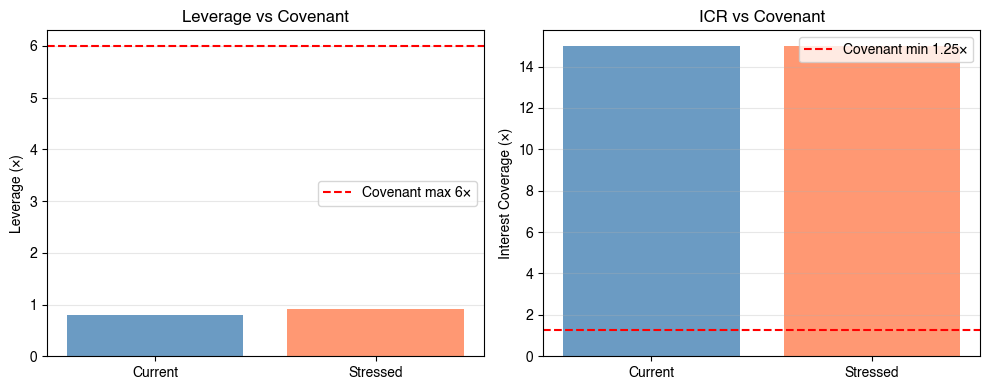


**Takeaway:** Under these illustrative covenants headroom is large versus current metrics.
The stress scenario narrows it but remains well inside both limits.
Replace thresholds with your actual facility terms for a live deal.


In [5]:
# ── Covenant thresholds (illustrative — replace with actual facility terms) ─
COV_MAX_LEV = 6.0
COV_MIN_ICR = 1.25
COV_MIN_Z   = 1.5

headroom_lev = COV_MAX_LEV - leverage if not np.isnan(leverage) else np.nan
headroom_icr = (interest_coverage - COV_MIN_ICR) \
    if interest_coverage not in (np.inf, np.nan) and not np.isnan(interest_coverage) else np.nan
headroom_z   = (altman_z - COV_MIN_Z) if not np.isnan(altman_z) else np.nan

# ── Stress scenario ──────────────────────────────────────────────────────────
REV_SHOCK    = 0.90   # −10% revenue
MARGIN_SHOCK = -0.02  # −200 bps EBITDA margin

ebitda_stress = (data["ebitda"] or 0) * REV_SHOCK * (1 + MARGIN_SHOCK)
lev_stress    = net_debt / ebitda_stress if ebitda_stress > 0 else np.nan
icr_stress    = ebitda_stress / interest_exp if interest_exp and interest_exp > 0 else np.nan

# ── Summary table ────────────────────────────────────────────────────────────
print("Covenant headroom (current vs thresholds):")
display(pd.DataFrame({
    "Metric":        ["Leverage (×)", "Interest Coverage (×)", "Altman Z"],
    "Current":       [leverage,
                      interest_coverage if interest_coverage != np.inf else np.nan,
                      altman_z],
    "Threshold":     [COV_MAX_LEV, COV_MIN_ICR, COV_MIN_Z],
    "Headroom":      [headroom_lev, headroom_icr, headroom_z],
    "Under stress":  [lev_stress, icr_stress, "—"],
}))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]   # Leverage (lower is better)
ax.bar(["Current", "Stressed"],
       [leverage if not np.isnan(leverage) else 0,
        lev_stress if not np.isnan(lev_stress) else 0],
       color=["steelblue", "coral"], alpha=0.8)
ax.axhline(COV_MAX_LEV, color="red", ls="--", label=f"Covenant max {COV_MAX_LEV:.0f}×")
ax.set_ylabel("Leverage (×)"); ax.set_title("Leverage vs Covenant")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]   # ICR (higher is better)
icr_cur = min(interest_coverage, 15) if interest_coverage != np.inf else 10
icr_st  = min(icr_stress, 15) if not np.isnan(icr_stress) else 0
ax.bar(["Current", "Stressed"], [icr_cur, icr_st], color=["steelblue", "coral"], alpha=0.8)
ax.axhline(COV_MIN_ICR, color="red", ls="--", label=f"Covenant min {COV_MIN_ICR:.2f}×")
ax.set_ylabel("Interest Coverage (×)"); ax.set_title("ICR vs Covenant")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

display(Markdown("""
**Takeaway:** Under these illustrative covenants headroom is large versus current metrics.
The stress scenario narrows it but remains well inside both limits.
Replace thresholds with your actual facility terms for a live deal.
"""))

## 6. Sensitivity Analysis — Revenue × Margin Shocks

Joint grids showing **Leverage** and **ICR** under simultaneous revenue and margin stresses. Net debt and interest are held fixed, so all variation flows through EBITDA.

Leverage (×) under stress:


,Rev -15%,Rev -10%,Rev -5%,Rev +0%,Rev +5%
Margin -3%,0.97,0.92,0.87,0.83,0.79
Margin -2%,0.96,0.91,0.86,0.82,0.78
Margin +0%,0.94,0.89,0.85,0.80,0.76
Margin +2%,0.93,0.87,0.83,0.79,0.75


Interest Coverage (×) under stress:


,Rev -15%,Rev -10%,Rev -5%,Rev +0%,Rev +5%
Margin -3%,17.77,18.82,19.87,20.91,21.96
Margin -2%,17.96,19.01,20.07,21.13,22.18
Margin +0%,18.32,19.40,20.48,21.56,22.64
Margin +2%,18.69,19.79,20.89,21.99,23.09


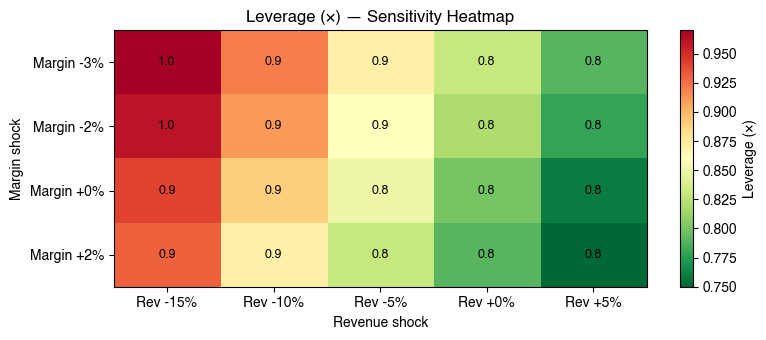

In [6]:
# ── Shock vectors ────────────────────────────────────────────────────────────
rev_changes    = [-0.15, -0.10, -0.05, 0.00, +0.05]
margin_changes = [-0.03, -0.02,  0.00, +0.02]

rev_labels    = [f"Rev {r:+.0%}" for r in rev_changes]
margin_labels = [f"Margin {m:+.0%}" for m in margin_changes]

def stress_ebitda(rev_pct, margin_pct, base=data):
    """Return stressed EBITDA given proportional revenue and margin changes."""
    return (base["ebitda"] or 0) * (1 + rev_pct) * (1 + margin_pct)


# Build grids
sens_lev = pd.DataFrame(
    [[round(net_debt / stress_ebitda(r, m), 2) for r in rev_changes] for m in margin_changes],
    index=margin_labels, columns=rev_labels
)
sens_icr = pd.DataFrame(
    [[round(stress_ebitda(r, m) / interest_exp, 2) if interest_exp and interest_exp > 0 else np.nan
      for r in rev_changes] for m in margin_changes],
    index=margin_labels, columns=rev_labels
)

print("Leverage (×) under stress:")
display(sens_lev)

print("Interest Coverage (×) under stress:")
display(sens_icr)

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(sens_lev.values.astype(float), cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(rev_changes)));    ax.set_xticklabels(rev_labels)
ax.set_yticks(range(len(margin_changes))); ax.set_yticklabels(margin_labels)
ax.set_xlabel("Revenue shock"); ax.set_ylabel("Margin shock")
ax.set_title("Leverage (×) — Sensitivity Heatmap")
for i in range(len(margin_changes)):
    for j in range(len(rev_changes)):
        ax.text(j, i, f"{sens_lev.values[i, j]:.1f}",
                ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im, ax=ax, label="Leverage (×)")
plt.tight_layout(); plt.show()

## 7. Summary Dashboard — IMAX vs LBO Benchmarks

Four-panel chart showing where IMAX sits relative to typical LBO screening thresholds.

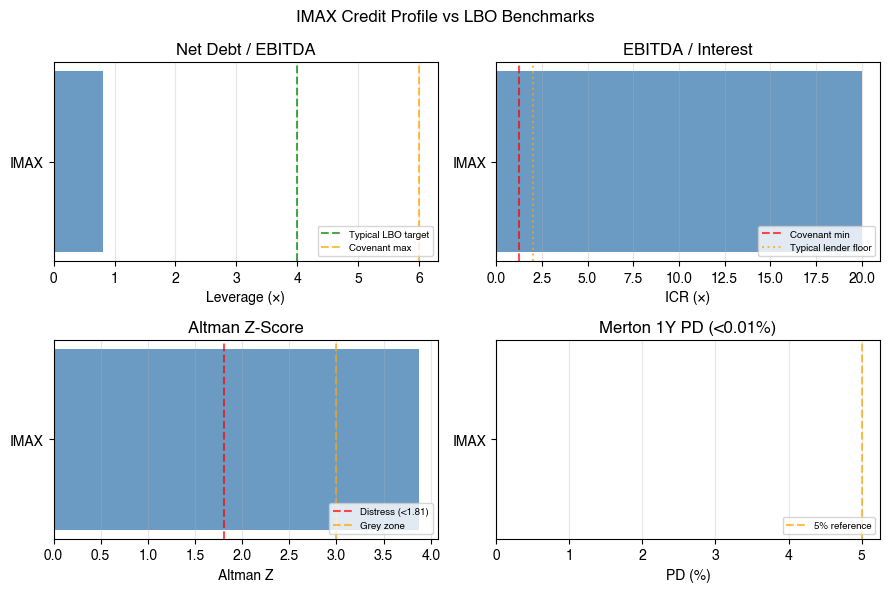


### Summary

| Metric | IMAX (current) | Signal |
|--------|---------------|--------|
| Net Debt / EBITDA | 0.80× | Well below 4–6× LBO range — significant capacity |
| Interest Coverage | 21.6× | Strong; servicing capacity not a concern today |
| Altman Z-Score | 3.88 (safe) | In the **safe** zone |
| Merton 1Y PD | <0.01% | Negligible default risk at current capital structure |

**Bottom line:** IMAX's unlevered balance sheet offers substantial debt capacity for an LBO.
The debt capacity curve (§4) shows the optimal leverage range is ~4–6×, consistent with
the proposed structure. Key risk is EBITDA volatility — the sensitivity analysis (§6)
confirms headroom remains adequate under a mild stress scenario.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# ── Leverage ─────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.barh(["IMAX"], [leverage if not np.isnan(leverage) else 0], color="steelblue", alpha=0.8)
ax.axvline(4, color="green",  ls="--", alpha=0.7, label="Typical LBO target")
ax.axvline(6, color="orange", ls="--", alpha=0.7, label="Covenant max")
ax.set_xlabel("Leverage (×)"); ax.set_title("Net Debt / EBITDA")
ax.legend(loc="lower right", fontsize=7); ax.grid(True, alpha=0.3, axis="x")

# ── Interest Coverage ────────────────────────────────────────────────────────
ax = axes[0, 1]
icr_plot = min(interest_coverage, 20) if interest_coverage != np.inf else 15
ax.barh(["IMAX"], [icr_plot], color="steelblue", alpha=0.8)
ax.axvline(COV_MIN_ICR, color="red", ls="--", alpha=0.7, label="Covenant min")
ax.axvline(2,           color="orange", ls=":", alpha=0.7, label="Typical lender floor")
ax.set_xlabel("ICR (×)"); ax.set_title("EBITDA / Interest")
ax.legend(loc="lower right", fontsize=7); ax.grid(True, alpha=0.3, axis="x")

# ── Altman Z ─────────────────────────────────────────────────────────────────
ax = axes[1, 0]
z_val = altman_z if not np.isnan(altman_z) else 0
ax.barh(["IMAX"], [z_val], color="steelblue", alpha=0.8)
ax.axvline(1.81, color="red",    ls="--", alpha=0.7, label="Distress (<1.81)")
ax.axvline(2.99, color="orange", ls="--", alpha=0.7, label="Grey zone")
ax.set_xlabel("Altman Z"); ax.set_title("Altman Z-Score")
ax.legend(loc="lower right", fontsize=7); ax.grid(True, alpha=0.3, axis="x")

# ── Merton PD ────────────────────────────────────────────────────────────────
ax = axes[1, 1]
pd_plot = min(PD * 100 if not np.isnan(PD) else 0, 20)
ax.barh(["IMAX"], [pd_plot], color="steelblue", alpha=0.8)
ax.axvline(5, color="orange", ls="--", alpha=0.7, label="5% reference")
ax.set_xlabel("PD (%)")
ax.set_title(f"Merton 1Y PD ({pd_str})")
ax.legend(loc="lower right", fontsize=7); ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("IMAX Credit Profile vs LBO Benchmarks", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

display(Markdown(f"""
### Summary

| Metric | IMAX (current) | Signal |
|--------|---------------|--------|
| Net Debt / EBITDA | {fmt_lev(leverage)} | Well below 4–6× LBO range — significant capacity |
| Interest Coverage | {fmt_icr(interest_coverage)} | Strong; servicing capacity not a concern today |
| Altman Z-Score | {altman_z:.2f} ({z_band}) | In the **safe** zone |
| Merton 1Y PD | {pd_str} | Negligible default risk at current capital structure |

**Bottom line:** IMAX's unlevered balance sheet offers substantial debt capacity for an LBO.
The debt capacity curve (§4) shows the optimal leverage range is ~4–6×, consistent with
the proposed structure. Key risk is EBITDA volatility — the sensitivity analysis (§6)
confirms headroom remains adequate under a mild stress scenario.
"""))